# Bengaluru House Price Prediction using Deep Neural Network 

## 1. Import Libraries

In [3]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

In [4]:
df = pd.read_csv('/kaggle/input/datasets/mohamedelalfy01/bengalur/bengaluru_house_prices.csv')

print(f"Shape: {df.shape}")

Shape: (13320, 9)


## 3. Initial Dataset Inspection

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

Shape: (13320, 9)

Columns:
['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price']

First 5 rows:


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00



Data types:


,dtype
area_type,object
availability,object
location,object
size,object
society,object
total_sqft,object
bath,float64
balcony,float64
price,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


## 4. Missing Values

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_pct
})

display(missing_table[missing_table["Missing Values"] > 0])

,Missing Values,Missing %
society,5502,41.31
balcony,609,4.57
bath,73,0.55
size,16,0.12
location,1,0.01


## 5. Statistical Summary

In [7]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area_type,13320,4,Super built-up Area,8790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
availability,13320,81,Ready To Move,10581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,13319,1305,Whitefield,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,13304,31,2 BHK,5199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
society,7818,2688,GrrvaGr,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_sqft,13320,2117,1200,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bath,13247.0,NaN,NaN,NaN,2.69261,1.341458,1.0,2.0,2.0,3.0,40.0
balcony,12711.0,NaN,NaN,NaN,1.584376,0.817263,0.0,1.0,2.0,2.0,3.0
price,13320.0,NaN,NaN,NaN,112.565627,148.971674,8.0,50.0,72.0,120.0,3600.0


## 6. Target Distribution

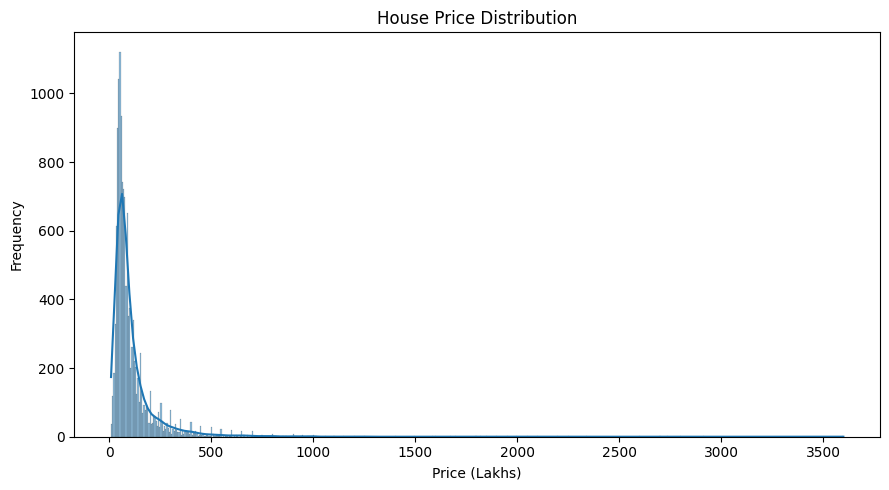

Target skewness: 8.064468821273252


In [8]:
plt.figure(figsize=(9, 5))
sns.histplot(df["price"].dropna(), kde=True)
plt.title("House Price Distribution")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Target skewness:", df["price"].skew())

## 7. Data Cleaning and Feature Engineering

In [9]:
df = df.copy()

# Remove duplicate rows
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {before - len(df)}")

# Fill missing numerical values
if "bath" in df.columns:
    df["bath"] = df["bath"].fillna(df["bath"].median())

if "balcony" in df.columns:
    df["balcony"] = df["balcony"].fillna(df["balcony"].median())

# Fill missing categorical values
if "location" in df.columns:
    df["location"] = df["location"].fillna("other")

if "size" in df.columns:
    df["size"] = df["size"].fillna(df["size"].mode()[0])

# Extract BHK from size
if "size" in df.columns:
    df["bhk"] = df["size"].astype(str).str.extract(r"(\d+)").astype(float)
    df.drop(columns=["size"], inplace=True)

# Convert total_sqft ranges such as "1200-1500" to their midpoint
def convert_sqft(value):
    value = str(value).strip()

    if "-" in value:
        parts = value.split("-")
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except (ValueError, TypeError):
            return np.nan

    try:
        return float(value)
    except (ValueError, TypeError):
        return np.nan

if "total_sqft" in df.columns:
    df["total_sqft"] = df["total_sqft"].apply(convert_sqft)

# Remove rows where essential variables are unavailable
required = [c for c in ["price", "total_sqft", "bhk"] if c in df.columns]
df = df.dropna(subset=required).reset_index(drop=True)

# Clean and group rare locations
if "location" in df.columns:
    df["location"] = df["location"].astype(str).str.strip()

    location_counts = df["location"].value_counts()
    rare_locations = location_counts[location_counts <= 10].index

    df["location"] = df["location"].apply(
        lambda x: "other" if x in rare_locations else x
    )

# Additional features
if {"total_sqft", "bhk"}.issubset(df.columns):
    df["sqft_per_bhk"] = df["total_sqft"] / df["bhk"]

if {"bath", "bhk"}.issubset(df.columns):
    df["bath_per_bhk"] = df["bath"] / df["bhk"]

# Remove invalid values
df = df.replace([np.inf, -np.inf], np.nan)

valid = (
    (df["price"] > 0) &
    (df["total_sqft"] > 0) &
    (df["bhk"] > 0)
)

if "bath" in df.columns:
    valid &= df["bath"] > 0

if "sqft_per_bhk" in df.columns:
    valid &= df["sqft_per_bhk"].between(200, 10000)

df = df.loc[valid].dropna().reset_index(drop=True)

print("Final cleaned shape:", df.shape)
display(df.head())

Duplicates removed: 529
Final cleaned shape: (7439, 11)


,area_type,availability,location,society,total_sqft,bath,balcony,price,bhk,sqft_per_bhk,bath_per_bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2.0,528.0,1.00
1,Plot Area,Ready To Move,Chikka Tirupathi,Theanmp,2600.0,5.0,3.0,120.00,4.0,650.0,1.25
2,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3.0,507.0,1.00
3,Super built-up Area,Ready To Move,Whitefield,DuenaTa,1170.0,2.0,1.0,38.00,2.0,585.0,1.00
4,Super built-up Area,18-May,Old Airport Road,Jaades,2732.0,4.0,2.0,204.00,4.0,683.0,1.00


## 8. Post-Cleaning Checks

In [10]:
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nNumerical summary:")
display(df.describe().T)

Missing values:


area_type       0
availability    0
location        0
society         0
total_sqft      0
bath            0
balcony         0
price           0
bhk             0
sqft_per_bhk    0
bath_per_bhk    0
dtype: int64


Numerical summary:


,count,mean,std,min,25%,50%,75%,max
total_sqft,7439.0,1555.106805,923.380030,284.000000,1125.000000,1332.0,1700.0,36000.0
bath,7439.0,2.493346,0.925384,1.000000,2.000000,2.0,3.0,14.0
balcony,7439.0,1.643097,0.773782,0.000000,1.000000,2.0,2.0,3.0
price,7439.0,102.616718,118.661184,8.000000,50.000000,70.5,110.0,2700.0
bhk,7439.0,2.564189,0.763434,1.000000,2.000000,3.0,3.0,11.0
sqft_per_bhk,7439.0,595.788444,195.346798,200.000000,503.166667,570.0,640.0,9000.0
bath_per_bhk,7439.0,0.974956,0.172661,0.333333,1.000000,1.0,1.0,2.0


## 9. EDA — Price vs Total Area

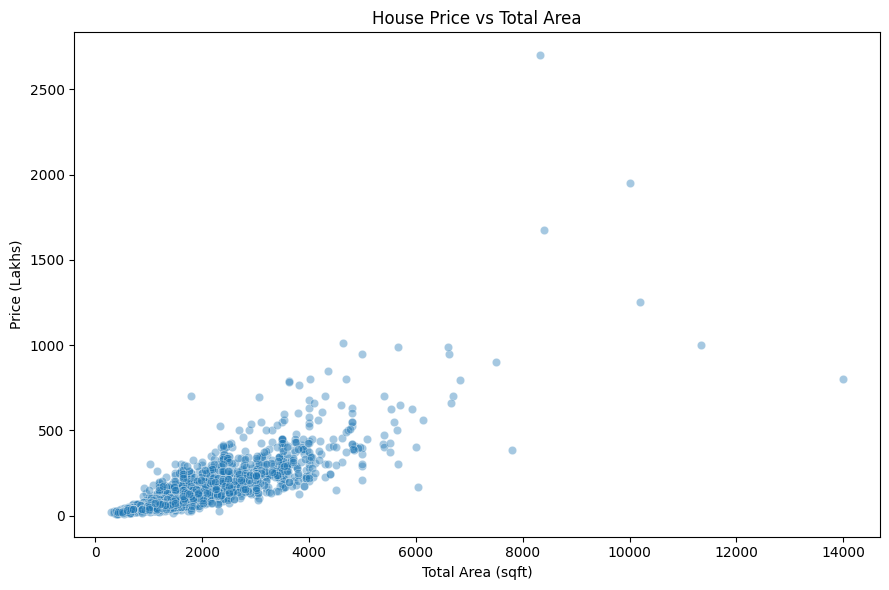

In [11]:
sample = df.sample(min(5000, len(df)), random_state=SEED)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=sample,
    x="total_sqft",
    y="price",
    alpha=0.4
)
plt.title("House Price vs Total Area")
plt.xlabel("Total Area (sqft)")
plt.ylabel("Price (Lakhs)")
plt.tight_layout()
plt.show()

## 10. EDA — Price vs BHK

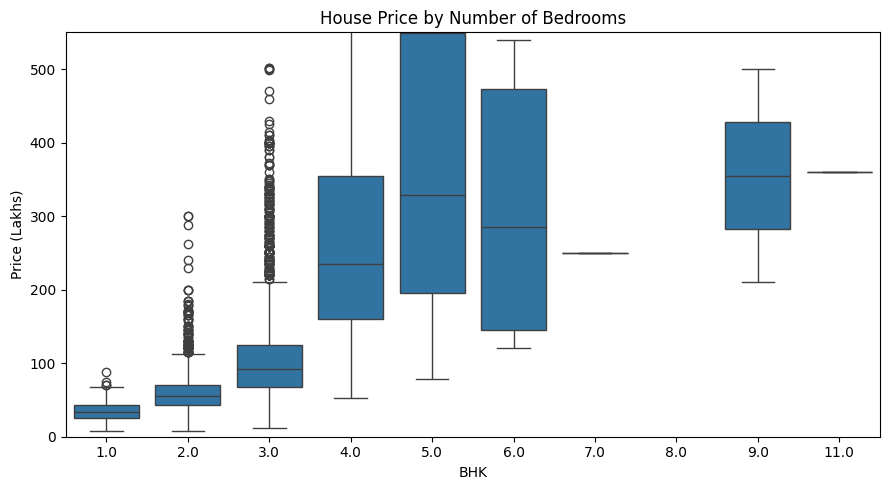

In [12]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="bhk", y="price")
plt.title("House Price by Number of Bedrooms")
plt.xlabel("BHK")
plt.ylabel("Price (Lakhs)")
plt.ylim(0, df["price"].quantile(0.99))
plt.tight_layout()
plt.show()

## 11. Numerical Correlation Matrix

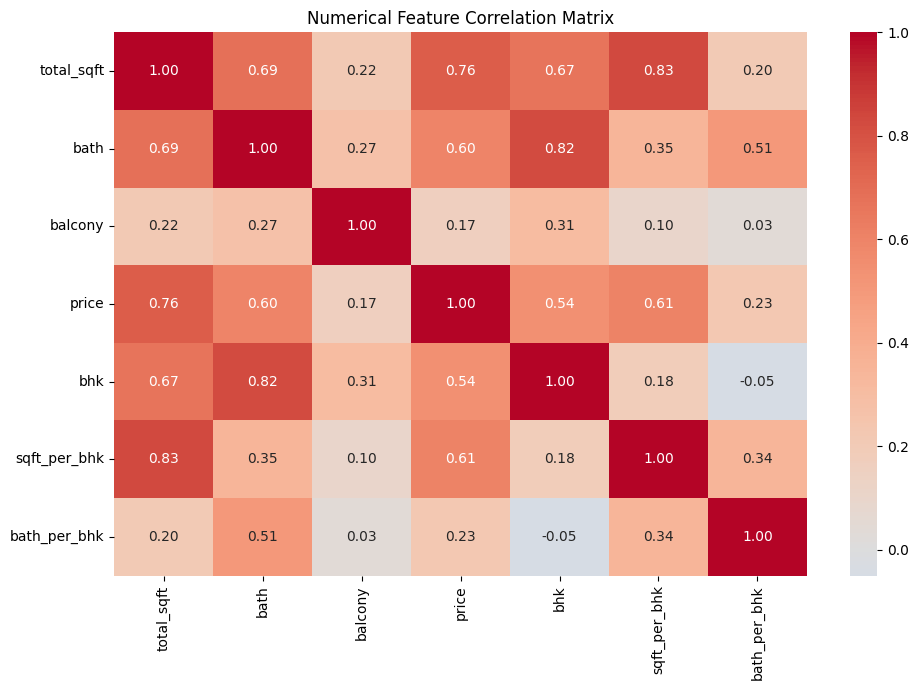

In [13]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 12. Prepare Features and Target

In [14]:
X = df.drop(columns=["price"])
y = df["price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nCategorical features:")
print(X.select_dtypes(include=["object"]).columns.tolist())

print("\nNumerical features:")
print(X.select_dtypes(include=np.number).columns.tolist())

Features shape: (7439, 10)
Target shape: (7439,)

Categorical features:
['area_type', 'availability', 'location', 'society']

Numerical features:
['total_sqft', 'bath', 'balcony', 'bhk', 'sqft_per_bhk', 'bath_per_bhk']


## 13. Train / Validation / Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=SEED
)

print(f"Train      : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Test       : {X_test.shape}")

Train      : (4760, 10)
Validation : (1191, 10)
Test       : (1488, 10)


## 14. One-Hot Encoding

In [16]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_val_cat = encoder.transform(X_val[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

print("Categorical columns:", categorical_cols)
print("Encoded categorical features:", X_train_cat.shape[1])

Categorical columns: ['area_type', 'availability', 'location', 'society']
Encoded categorical features: 2365


## 15. Standardize Numerical Features

In [17]:
from sklearn.preprocessing import StandardScaler

feature_scaler = StandardScaler()

X_train_num = feature_scaler.fit_transform(X_train[numerical_cols])
X_val_num = feature_scaler.transform(X_val[numerical_cols])
X_test_num = feature_scaler.transform(X_test[numerical_cols])

print("Numerical features scaled:", len(numerical_cols))

Numerical features scaled: 6


## 16. Combine Processed Features

In [18]:
X_train_processed = np.hstack([X_train_num, X_train_cat])
X_val_processed = np.hstack([X_val_num, X_val_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])

print("X_train:", X_train_processed.shape)
print("X_val  :", X_val_processed.shape)
print("X_test :", X_test_processed.shape)

X_train: (4760, 2371)
X_val  : (1191, 2371)
X_test : (1488, 2371)


## 17. Log-Transform the Target

In [19]:
# Log transformation reduces the effect of very expensive houses
# and makes the regression target less skewed.

y_train_log = np.log1p(y_train.to_numpy())
y_val_log = np.log1p(y_val.to_numpy())
y_test_log = np.log1p(y_test.to_numpy())

print("Original target:")
display(y_train.describe())

print("\nLog-transformed target:")
display(pd.Series(y_train_log).describe())

Original target:


count    4760.000000
mean      104.355741
std       128.368400
min         8.000000
25%        50.000000
50%        71.000000
75%       110.000000
max      2700.000000
Name: price, dtype: float64


Log-transformed target:


count    4760.000000
mean        4.378444
std         0.664034
min         2.197225
25%         3.931826
50%         4.276666
75%         4.709530
max         7.901377
dtype: float64

## 18. Build the Deep Neural Network

In [20]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

np.random.seed(SEED)
tf.random.set_seed(SEED)

model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),

    Dense(256, activation="relu", kernel_regularizer=l2(1e-5)),
    BatchNormalization(),
    Dropout(0.20),

    Dense(128, activation="relu", kernel_regularizer=l2(1e-5)),
    BatchNormalization(),
    Dropout(0.20),

    Dense(64, activation="relu", kernel_regularizer=l2(1e-5)),
    Dropout(0.10),

    Dense(1, activation="linear")
])

model.summary()

2026-08-14 15:58:47.924970: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       607,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,985 (2.48 MB)

 Trainable params: 649,217 (2.48 MB)

 Non-trainable params: 768 (3.00 KB)

## 19. Compile the Model

In [21]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.metrics import MeanAbsoluteError, RootMeanSquaredError

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=Huber(),
    metrics=[
        MeanAbsoluteError(name="mae"),
        RootMeanSquaredError(name="rmse")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


## 20. Train the Model

In [22]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_processed,
    y_train_log,
    validation_data=(X_val_processed, y_val_log),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/300
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.6627 - mae: 1.0468 - rmse: 1.4348 - val_loss: 0.5908 - val_mae: 1.0221 - val_rmse: 1.2381 - learning_rate: 0.0010
Epoch 2/300
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2881 - mae: 0.6232 - rmse: 0.7971 - val_loss: 0.2186 - val_mae: 0.5354 - val_rmse: 0.6783 - learning_rate: 0.0010
Epoch 3/300
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2325 - mae: 0.5461 - rmse: 0.7059 - val_loss: 0.1203 - val_mae: 0.3527 - val_rmse: 0.4945 - learning_rate: 0.0010
Epoch 4/300
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1969 - mae: 0.4966 - rmse: 0.6386 - val_loss: 0.0874 - val_mae: 0.3096 - val_rmse: 0.4115 - learning_rate: 0.0010
Epoch 5/300
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1756 - mae: 0.4690 - rmse: 0.5979 - val_loss: 0.0676 - val_mae: 0.2615 - val_rmse: 0.3607 - learning_rate: 0.0010
Epoch 6/300
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1611 - mae: 0.4455 - rmse: 0.5701 - val_loss: 0.084

## 21. Training Curves

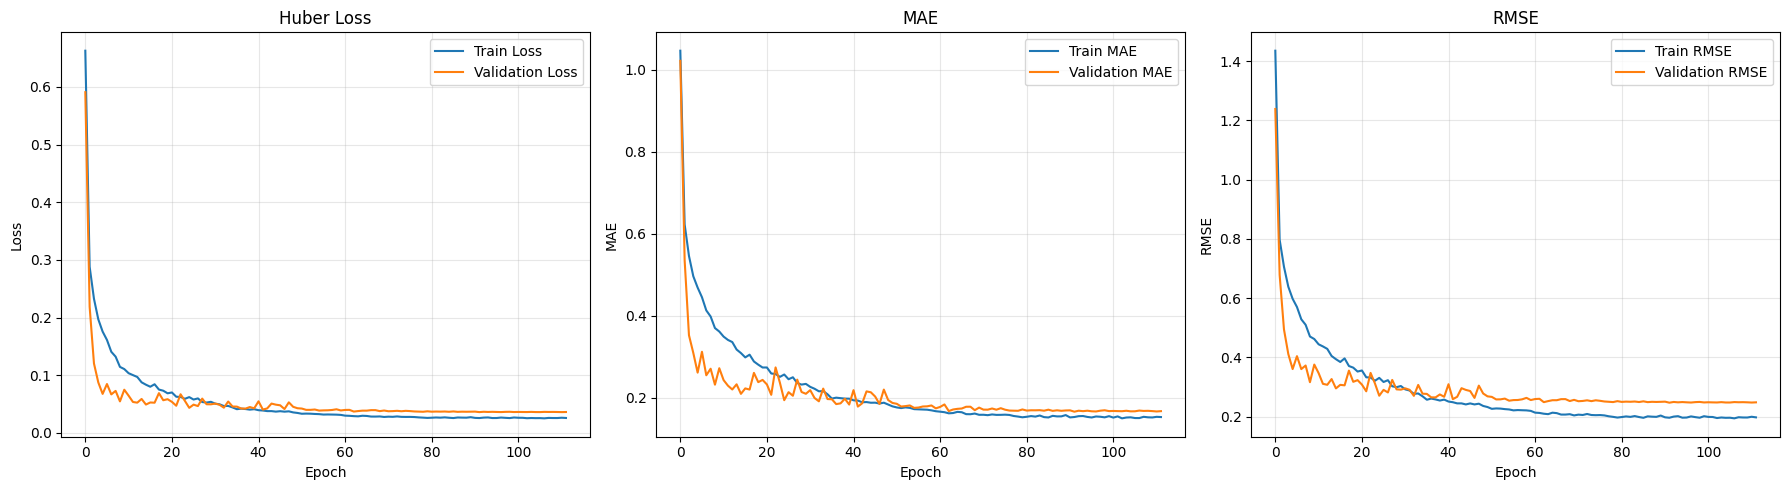

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_title("Huber Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["mae"], label="Train MAE")
axes[1].plot(history.history["val_mae"], label="Validation MAE")
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history.history["rmse"], label="Train RMSE")
axes[2].plot(history.history["val_rmse"], label="Validation RMSE")
axes[2].set_title("RMSE")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("RMSE")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 22. Generate Test Predictions

In [24]:
y_pred_log = model.predict(
    X_test_processed,
    verbose=0
).ravel()

# Convert predictions back to Lakhs
y_pred = np.expm1(y_pred_log)

# House prices cannot be negative
y_pred = np.maximum(y_pred, 0)

print("Predictions generated:", len(y_pred))

Predictions generated: 1488


## 23. Final Model Evaluation

In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("=" * 55)
print("FINAL DNN PERFORMANCE")
print("=" * 55)
print(f"MAE  : {mae:.3f} Lakhs")
print(f"RMSE : {rmse:.3f} Lakhs")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")
print("=" * 55)

FINAL DNN PERFORMANCE
MAE  : 37.522 Lakhs
RMSE : 469.200 Lakhs
R²   : -20.2912
MAPE : 18.25%
